# IMPORTS

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb


# DATA

In [5]:
DATA_PATH = r"C:\Users\anura\Thesis\sme_final_merged_fixed.xlsx"
OUT_DIR = r"C:\Users\anura\Thesis\ml_outputs_leakage_safe"
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42
SPLIT_DATE = "2023-01-01"

# FUNCTIONS

In [9]:
def get_feature_names(prep: ColumnTransformer, cat_cols, num_cols):
    names = []
    if len(cat_cols) > 0:
        ohe = prep.named_transformers_["cat"]
        names.extend(list(ohe.get_feature_names_out(cat_cols)))
    names.extend(list(num_cols))
    return names

def safe_write_csv(df_, filename):
    path = os.path.join(OUT_DIR, filename)
    df_.to_csv(path, index=False)
    return path

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred))
    }

def classification_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "ROC_AUC": float(roc_auc_score(y_true, y_proba))
    }



# DATA VIEW

In [13]:
df = pd.read_excel(DATA_PATH)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)


In [15]:
df

,date,sku,region,customer_segment,product_category,base_price,market_index,consumer_sentiment,holiday_flag,competitor_promotions,...,retention_rate,hr_compliance_incidents,inventory_level,lead_time_days,supplier_rating,logistics_delay_hours,demand_forecast,warehouse_capacity_use,spoilage_rate,high_demand_flag
0,2020-01-01,SKU_010,West,Large_B2B,C,20,100.993428,46.327105,0,0,...,0.98,0,11246.749231,7.868726,3.56473,4.483904,5130.384568,0.766666,0.021209,0
1,2020-01-01,SKU_024,West,Retail,A,10,100.993428,46.327105,0,0,...,0.98,0,11246.749231,7.868726,3.56473,4.483904,5130.384568,0.766666,0.021209,0
2,2020-01-01,SKU_016,North,Retail,B,15,100.993428,46.327105,0,0,...,0.98,0,11246.749231,7.868726,3.56473,4.483904,5130.384568,0.766666,0.021209,0
3,2020-01-01,SKU_009,South,SME_B2B,D,30,100.993428,46.327105,0,0,...,0.98,0,11246.749231,7.868726,3.56473,4.483904,5130.384568,0.766666,0.021209,0
4,2020-01-01,SKU_021,West,SME_B2B,C,20,100.993428,46.327105,0,0,...,0.98,0,11246.749231,7.868726,3.56473,4.483904,5130.384568,0.766666,0.021209,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-12-31,SKU_003,South,SME_B2B,B,15,128.923088,52.235016,1,0,...,0.98,0,8264.547995,8.319442,3.31543,4.147140,4832.193981,0.601962,0.019342,1
39996,2023-12-31,SKU_014,East,Large_B2B,D,30,128.923088,52.235016,1,0,...,0.98,0,8264.547995,8.319442,3.31543,4.147140,4832.193981,0.601962,0.019342,0
39997,2023-12-31,SKU_015,East,Retail,A,10,128.923088,52.235016,1,0,...,0.98,0,8264.547995,8.319442,3.31543,4.147140,4832.193981,0.601962,0.019342,1
39998,2023-12-31,SKU_023,West,Retail,D,30,128.923088,52.235016,1,0,...,0.98,0,8264.547995,8.319442,3.31543,4.147140,4832.193981,0.601962,0.019342,0


# KEY VALUES

In [17]:
if "revenue" not in df.columns:
    raise ValueError("Missing required column: revenue")
if "high_demand_flag" not in df.columns:
    raise ValueError("Missing required column: high_demand_flag")

y_reg = df["revenue"].astype(float)
y_clf = df["high_demand_flag"].astype(int)

# LEAKAGE CONTROL

In [21]:

LEAKY_FOR_REVENUE = [
    "total_revenue", "cogs", "opex", "capex",
    "profit", "profit_margin", "cash_flow"
]

LEAKY_FOR_DEMAND = [
    "units_sold"
]

X_all = df.drop(columns=["revenue", "high_demand_flag"], errors="ignore").copy()

#safe time features 
X_all["year"] = df["date"].dt.year
X_all["month"] = df["date"].dt.month
X_all["quarter"] = df["date"].dt.quarter
X_all["dayofweek"] = df["date"].dt.dayofweek

# Drop raw date
X_all = X_all.drop(columns=["date"], errors="ignore")

# Features for each task 
X_reg = X_all.drop(columns=[c for c in LEAKY_FOR_REVENUE if c in X_all.columns], errors="ignore")
X_clf = X_all.drop(columns=[c for c in LEAKY_FOR_DEMAND if c in X_all.columns], errors="ignore")


# TRAIN-TEST SPLIT

In [25]:
train_mask = df["date"] < pd.Timestamp(SPLIT_DATE)
test_mask  = df["date"] >= pd.Timestamp(SPLIT_DATE)

# Regression splits
X_reg_train, X_reg_test = X_reg.loc[train_mask], X_reg.loc[test_mask]
y_reg_train, y_reg_test = y_reg.loc[train_mask], y_reg.loc[test_mask]

# Classification splits
X_clf_train, X_clf_test = X_clf.loc[train_mask], X_clf.loc[test_mask]
y_clf_train, y_clf_test = y_clf.loc[train_mask], y_clf.loc[test_mask]

if len(X_reg_test) == 0 or len(X_reg_train) == 0:
    raise ValueError("Empty train/test after split for regression. Check SPLIT_DATE.")
if len(X_clf_test) == 0 or len(X_clf_train) == 0:
    raise ValueError("Empty train/test after split for classification. Check SPLIT_DATE.")

# ENCODER

In [29]:
cat_reg = X_reg.select_dtypes(include=["object"]).columns.tolist()
num_reg = X_reg.select_dtypes(exclude=["object"]).columns.tolist()

prep_reg = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_reg),
     ("num", "passthrough", num_reg)]
)

cat_clf = X_clf.select_dtypes(include=["object"]).columns.tolist()
num_clf = X_clf.select_dtypes(exclude=["object"]).columns.tolist()

prep_clf = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_clf),
     ("num", "passthrough", num_clf)]
)


# MODEL

In [33]:
xgb_reg = XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.85, colsample_bytree=0.85,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg = RandomForestRegressor(
    n_estimators=600, max_depth=14,
    random_state=RANDOM_STATE, n_jobs=-1
)

xgb_clf = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.85, colsample_bytree=0.85,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf = RandomForestClassifier(
    n_estimators=600, max_depth=14,
    random_state=RANDOM_STATE, n_jobs=-1
)

# PIPELINE

In [37]:
pipe_xgb_reg = Pipeline([("prep", prep_reg), ("model", xgb_reg)])
pipe_rf_reg  = Pipeline([("prep", prep_reg), ("model", rf_reg)])

pipe_xgb_clf = Pipeline([("prep", prep_clf), ("model", xgb_clf)])
pipe_rf_clf  = Pipeline([("prep", prep_clf), ("model", rf_clf)])

# MODEL TRAINING AND METRICS

In [41]:
metrics = []

# --- Regression: XGB
pipe_xgb_reg.fit(X_reg_train, y_reg_train)
pred_xgb_reg = pipe_xgb_reg.predict(X_reg_test)
m = {"Model":"XGB_Reg", "Task":"Regression"}
m.update(regression_metrics(y_reg_test, pred_xgb_reg))
metrics.append(m)

# --- Regression: RF
pipe_rf_reg.fit(X_reg_train, y_reg_train)
pred_rf_reg = pipe_rf_reg.predict(X_reg_test)
m = {"Model":"RF_Reg", "Task":"Regression"}
m.update(regression_metrics(y_reg_test, pred_rf_reg))
metrics.append(m)

# --- Classification: XGB
pipe_xgb_clf.fit(X_clf_train, y_clf_train)
proba_xgb = pipe_xgb_clf.predict_proba(X_clf_test)[:, 1]
m = {"Model":"XGB_Clf", "Task":"Classification"}
m.update(classification_metrics(y_clf_test, proba_xgb))
metrics.append(m)

# --- Classification: RF
pipe_rf_clf.fit(X_clf_train, y_clf_train)
proba_rf = pipe_rf_clf.predict_proba(X_clf_test)[:, 1]
m = {"Model":"RF_Clf", "Task":"Classification"}
m.update(classification_metrics(y_clf_test, proba_rf))
metrics.append(m)

metrics_df = pd.DataFrame(metrics)
safe_write_csv(metrics_df, "model_metrics_comparison.csv")

'C:\\Users\\anura\\Thesis\\ml_outputs_leakage_safe\\model_metrics_comparison.csv'

In [47]:
metrics_df

,Model,Task,RMSE,MAE,R2,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGB_Reg,Regression,1.867006,0.848386,0.913564,NaN,NaN,NaN,NaN,NaN
1,RF_Reg,Regression,2.054082,0.272002,0.895872,NaN,NaN,NaN,NaN,NaN
2,XGB_Clf,Classification,NaN,NaN,NaN,0.822558,0.727407,0.544285,0.622661,0.862284
3,RF_Clf,Classification,NaN,NaN,NaN,0.825030,0.803834,0.462330,0.587028,0.860082


# FEATURE IMPORTNACE

In [15]:
# RF regression importance
imp = pipe_rf_reg.named_steps["model"].feature_importances_
fi = pd.DataFrame({"feature": reg_feature_names, "importance": imp}).sort_values("importance", ascending=False)
safe_write_csv(fi, "RF_Reg_feature_importance.csv")
metrics_df.loc[metrics_df["Model"]=="RF_Reg", "XAI"] = "RF feature_importances_"

# Feature names (post-transform) for classification
clf_feature_names = get_feature_names(pipe_xgb_clf.named_steps["prep"], cat_clf, num_clf)
X_clf_test_trans = pipe_xgb_clf.named_steps["prep"].transform(X_clf_test)


# MODEL METRICS

In [17]:
# RF classifier importance
imp = pipe_rf_clf.named_steps["model"].feature_importances_
fi = pd.DataFrame({"feature": clf_feature_names, "importance": imp}).sort_values("importance", ascending=False)
safe_write_csv(fi, "RF_Clf_feature_importance.csv")
metrics_df.loc[metrics_df["Model"]=="RF_Clf", "XAI"] = "RF feature_importances_"

# Save updated metrics with XAI column filled
safe_write_csv(metrics_df, "model_metrics_comparison.csv")

'C:\\Users\\anura\\Thesis\\ml_outputs_leakage_safe\\model_metrics_comparison.csv'

In [89]:
# ============================================================
# PREDICTIONS EXPORT
# ============================================================
preds = df.loc[test_mask, ["date"]].copy()
preds["actual_revenue"] = y_reg_test.values
preds["XGB_Reg_pred_revenue"] = pred_xgb_reg
preds["RF_Reg_pred_revenue"] = pred_rf_reg

preds["actual_high_demand_flag"] = y_clf_test.values
preds["XGB_Clf_proba_high_demand"] = proba_xgb
preds["RF_Clf_proba_high_demand"] = proba_rf
preds["XGB_Clf_pred_high_demand"] = (proba_xgb >= 0.5).astype(int)
preds["RF_Clf_pred_high_demand"] = (proba_rf >= 0.5).astype(int)

safe_write_csv(preds, "predictions_test_period.csv")

print("Saved to:", OUT_DIR)
print("Key outputs:")
print("- model_metrics_comparison.csv")
print("- predictions_test_period.csv")

Saved to: C:\Users\anura\Thesis\ml_outputs_leakage_safe
Key outputs:
- model_metrics_comparison.csv
- predictions_test_period.csv


# FEATURE IMPORTNACE VISUALS


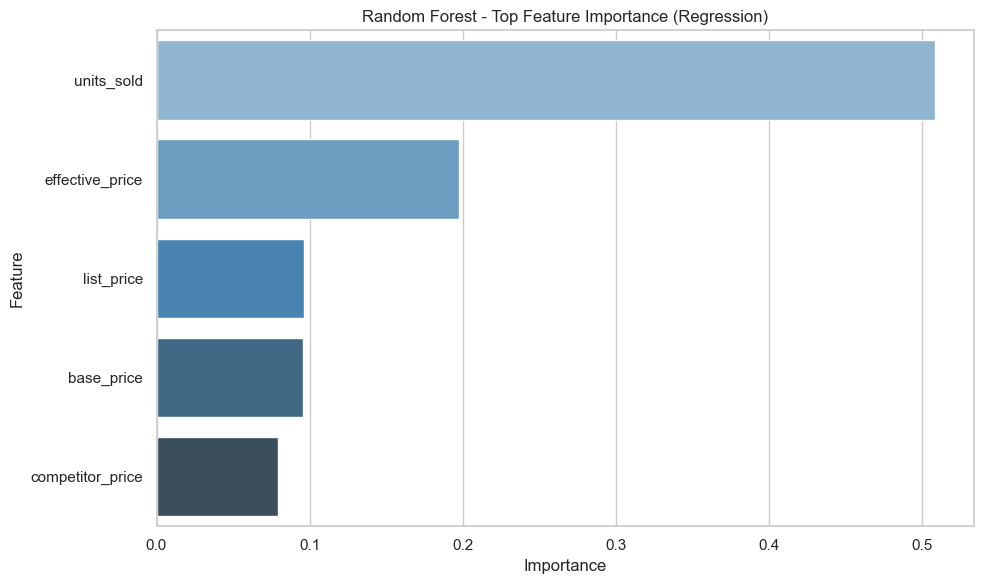

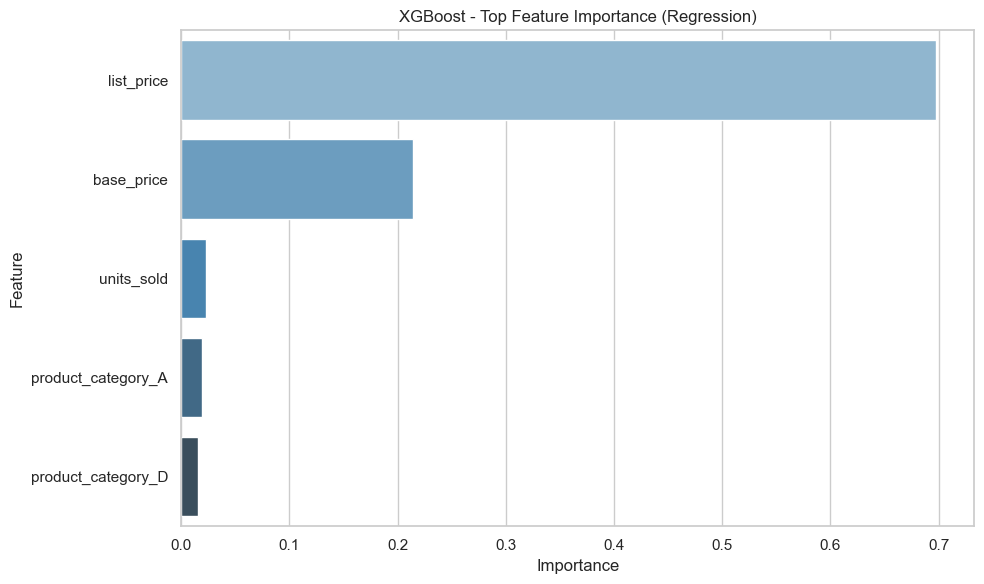

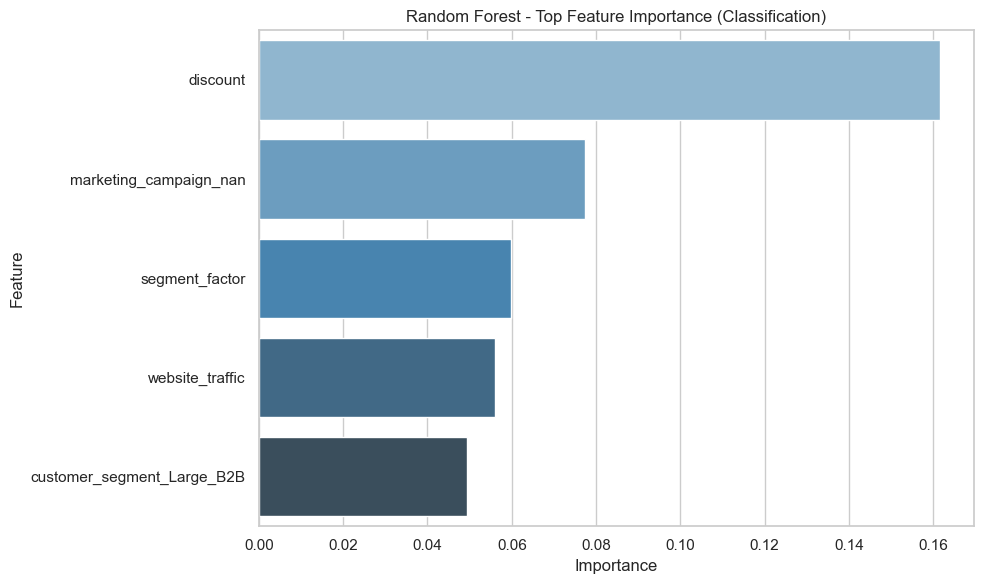

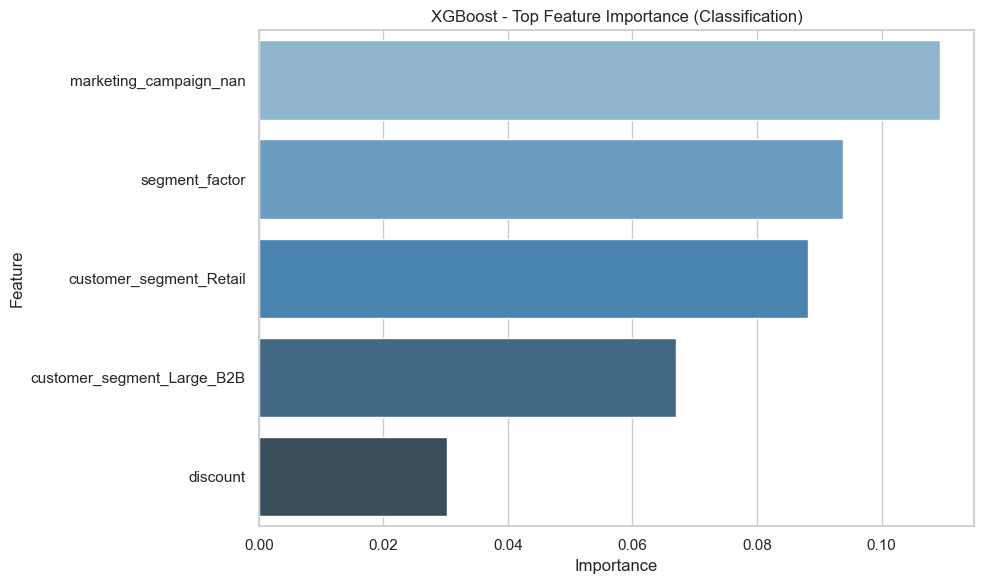

In [21]:
# Set the number of top features to display
top_n = 5

# ============================================================
# FEATURE IMPORTANCE VISUALIZATION (Random Forest & XGBoost)
# ============================================================
# Random Forest Feature Importance (Regression)
rf_reg_importance = pd.read_csv(os.path.join(OUT_DIR, "RF_Reg_feature_importance.csv"))
top_rf_reg = rf_reg_importance.head(top_n)  # Top N features

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=top_rf_reg, palette="Blues_d")
plt.title("Random Forest - Top Feature Importance (Regression)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "RF_Reg_Top_Feature_Importance.png"))
plt.show()

# XGBoost Feature Importance (Regression)
xgb_reg_importance = pd.read_csv(os.path.join(OUT_DIR, "XGB_Reg_feature_importance.csv"))
top_xgb_reg = xgb_reg_importance.head(top_n)  # Top N features

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=top_xgb_reg, palette="Blues_d")
plt.title("XGBoost - Top Feature Importance (Regression)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "XGB_Reg_Top_Feature_Importance.png"))
plt.show()

# Random Forest Feature Importance (Classification)
rf_clf_importance = pd.read_csv(os.path.join(OUT_DIR, "RF_Clf_feature_importance.csv"))
top_rf_clf = rf_clf_importance.head(top_n)  # Top N features

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=top_rf_clf, palette="Blues_d")
plt.title("Random Forest - Top Feature Importance (Classification)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "RF_Clf_Top_Feature_Importance.png"))
plt.show()

# XGBoost Feature Importance (Classification)
xgb_clf_importance = pd.read_csv(os.path.join(OUT_DIR, "XGB_Clf_feature_importance.csv"))
top_xgb_clf = xgb_clf_importance.head(top_n)  # Top N features

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=top_xgb_clf, palette="Blues_d")
plt.title("XGBoost - Top Feature Importance (Classification)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "XGB_Clf_Top_Feature_Importance.png"))
plt.show()


# LIME XAI

In [54]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [91]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

print("Generating LIME explanations...")

# Encode categorical features

def encode_categoricals(X_train, X_test):
    X_train_enc, X_test_enc = X_train.copy(), X_test.copy()
    encoders = {}
    cat_cols = X_train_enc.select_dtypes(include=['object', 'category']).columns
    
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X_train_enc[col], X_test_enc[col]]).astype(str)
        le.fit(combined)
        X_train_enc[col] = le.transform(X_train_enc[col].astype(str))
        X_test_enc[col] = le.transform(X_test_enc[col].astype(str))
        encoders[col] = le
    
    cat_indices = [X_train_enc.columns.get_loc(c) for c in cat_cols]
    return X_train_enc, X_test_enc, cat_indices, encoders

# Encode data
X_reg_tr, X_reg_te, cat_reg, enc_reg = encode_categoricals(X_reg_train, X_reg_test)
X_clf_tr, X_clf_te, cat_clf, enc_clf = encode_categoricals(X_clf_train, X_clf_test)

#
# Prediction wrapper
def make_wrapper(pipe, X_orig, X_enc, encoders, mode='reg'):
    def wrapper(X):
        df = pd.DataFrame(X, columns=X_enc.columns)
        for col, enc in encoders.items():
            df[col] = df[col].round().astype(int).clip(0, len(enc.classes_)-1)
            df[col] = enc.inverse_transform(df[col])
        df = df[X_orig.columns]
        return pipe.predict(df) if mode=='reg' else pipe.predict_proba(df)
    return wrapper

wrap_reg = make_wrapper(pipe_xgb_reg, X_reg_train, X_reg_tr, enc_reg, 'reg')
wrap_clf = make_wrapper(pipe_xgb_clf, X_clf_train, X_clf_tr, enc_clf, 'clf')



Generating LIME explanations...


# LIME REGRESSION AND CLASSIFICATION

In [92]:

# LIME Regression

print("\nRegression LIME")
exp_reg = lime.lime_tabular.LimeTabularExplainer(
    X_reg_tr.values, feature_names=X_reg_tr.columns.tolist(),
    categorical_features=cat_reg, mode='regression'
)
expl_reg = exp_reg.explain_instance(X_reg_te.iloc[0].values, wrap_reg, num_features=10)
expl_reg.show_in_notebook()
expl_reg.as_pyplot_figure()
plt.tight_layout()
plt.savefig('lime_reg.png', dpi=300, bbox_inches='tight')
plt.close()


# LIME Classification

print("\nClassification LIME")
exp_clf = lime.lime_tabular.LimeTabularExplainer(
    X_clf_tr.values, feature_names=X_clf_tr.columns.tolist(),
    categorical_features=cat_clf, mode='classification'
)
expl_clf = exp_clf.explain_instance(X_clf_te.iloc[0].values, wrap_clf, num_features=10)
expl_clf.show_in_notebook()
expl_clf.as_pyplot_figure()
plt.tight_layout()
plt.savefig('lime_clf.png', dpi=300, bbox_inches='tight')
plt.close()





Regression LIME



Classification LIME


In [ ]:
pip install lime
